# Tugas 1 - Klasifikasi Jamur dengan Naive Bayes

| Nama | NRP |
|------|-----|
| Suhail Ainur Rofiq | 5054251046 |

## Deskripsi Tugas
Pada tugas ini, kita akan menggunakan Mushroom Dataset dari UCI Machine Learning Repository.

Dataset dapat diakses melalui:
- https://www.kaggle.com/datasets/uciml/mushroom-classification

Untuk metadata / penjelasan mengenai dataset bisa mengakses link berikut:
- https://archive.ics.uci.edu/dataset/73/mushroom

Tujuan utama dari tugas ini adalah membangun dan membandingkan tiga varian Naive Bayes, yaitu Categorical NB, Bernoulli NB, dan Multinomial NB, untuk mengklasifikasikan apakah suatu jamur dapat dimakan (edible) atau beracun (poisonous).

Langkah-langkah yang harus dilakukan antara lain:
1. Persiapan Dataset dan Eksplorasi Awal
   - Memuat dataset, melihat struktur data, dan distribusi label.
2. Preprocessing
   - Memproses data agar siap digunakan untuk masing-masing varian Naive Bayes.
3. Eksperimen Model
   - Bangun model Categorical NB, Bernoulli NB, dan Multinomial NB.
4. Evaluasi Model
   - Hitung metrik evaluasi dan visualisasikan hasilnya.
5. Analisis dan Kesimpulan
   - Bandingkan hasil ketiga model dan berikan kesimpulan.

# 1. Persiapan Dataset dan Eksplorasi Awal

In [295]:
# Import library yang dibutuhkan (pandas, numpy, matplotlib, seaborn, sklearn, dll)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder, LabelEncoder
from sklearn.naive_bayes import CategoricalNB, BernoulliNB, MultinomialNB
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    roc_curve,
    auc,
    classification_report
)


In [296]:
# Load dataset dan tampilkan beberapa baris pertama.
# Semua nilai pada dataset berupa single character yang merupakan kode singkatan dari kategori.
# Contoh: pada kolom class, e = edible dan p = poisonous.

df = pd.read_csv('mushrooms.csv')
df.info()
df.head()

<class 'pandas.DataFrame'>
RangeIndex: 8124 entries, 0 to 8123
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   class                     8124 non-null   str  
 1   cap-shape                 8124 non-null   str  
 2   cap-surface               8124 non-null   str  
 3   cap-color                 8124 non-null   str  
 4   bruises                   8124 non-null   str  
 5   odor                      8124 non-null   str  
 6   gill-attachment           8124 non-null   str  
 7   gill-spacing              8124 non-null   str  
 8   gill-size                 8124 non-null   str  
 9   gill-color                8124 non-null   str  
 10  stalk-shape               8124 non-null   str  
 11  stalk-root                8124 non-null   str  
 12  stalk-surface-above-ring  8124 non-null   str  
 13  stalk-surface-below-ring  8124 non-null   str  
 14  stalk-color-above-ring    8124 non-null   str  
 15

,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,p,x,s,n,t,p,f,c,n,k,...,s,w,w,p,w,o,p,k,s,u
1,e,x,s,y,t,a,f,c,b,k,...,s,w,w,p,w,o,p,n,n,g
2,e,b,s,w,t,l,f,c,b,n,...,s,w,w,p,w,o,p,n,n,m
3,p,x,y,w,t,p,f,c,n,n,...,s,w,w,p,w,o,p,k,s,u
4,e,x,s,g,f,n,f,w,b,k,...,s,w,w,p,w,o,e,n,a,g


In [297]:
df.describe(include='object')

C:\Users\LAPTOPKU\AppData\Local\Temp\ipykernel_21536\87514550.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include='object')


,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
count,8124,8124,8124,8124,8124,8124,8124,8124,8124,8124,...,8124,8124,8124,8124,8124,8124,8124,8124,8124,8124
unique,2,6,4,10,2,9,2,2,2,12,...,4,9,9,1,4,3,5,9,6,7
top,e,x,y,n,f,n,f,c,b,b,...,s,w,w,p,w,o,p,w,v,d
freq,4208,3656,3244,2284,4748,3528,7914,6812,5612,1728,...,4936,4464,4384,8124,7924,7488,3968,2388,4040,3148


Menampilkan informasi dasar

In [298]:
# Tampilkan informasi dasar dataset: jumlah baris dan kolom, tipe data, dan jumlah missing value.
# Perhatikan kolom stalk-root yang memiliki nilai '?' sebagai representasi missing value.
df.shape
missing_question = (df == '?').sum()
print(df.shape)
print(df.dtypes)
print(df.isnull().sum())
print(missing_question[missing_question > 0])


(8124, 23)
class                       str
cap-shape                   str
cap-surface                 str
cap-color                   str
bruises                     str
odor                        str
gill-attachment             str
gill-spacing                str
gill-size                   str
gill-color                  str
stalk-shape                 str
stalk-root                  str
stalk-surface-above-ring    str
stalk-surface-below-ring    str
stalk-color-above-ring      str
stalk-color-below-ring      str
veil-type                   str
veil-color                  str
ring-number                 str
ring-type                   str
spore-print-color           str
population                  str
habitat                     str
dtype: object
class                       0
cap-shape                   0
cap-surface                 0
cap-color                   0
bruises                     0
odor                        0
gill-attachment             0
gill-spacing                0

Melihat berapa nilai unik yang ada pada setiap kolom

In [299]:
# Tampilkan jumlah nilai unik pada setiap fitur.
# Perhatikan variasi jumlah kategori antar fitur, misalnya veil-type hanya punya 1 nilai unik.
# 1. Hitung jumlah nilai unik per fitur
print(df.nunique())

# 2. Cek fitur yang hanya memiliki 1 nilai unik (misal: veil-type)
fitur_konstan = df.nunique()[df.nunique() == 1]
print(fitur_konstan)


class                        2
cap-shape                    6
cap-surface                  4
cap-color                   10
bruises                      2
odor                         9
gill-attachment              2
gill-spacing                 2
gill-size                    2
gill-color                  12
stalk-shape                  2
stalk-root                   5
stalk-surface-above-ring     4
stalk-surface-below-ring     4
stalk-color-above-ring       9
stalk-color-below-ring       9
veil-type                    1
veil-color                   4
ring-number                  3
ring-type                    5
spore-print-color            9
population                   6
habitat                      7
dtype: int64
veil-type    1
dtype: int64


Melihat persentase ? pada stalk root

In [300]:
persen_missing = (df['stalk-root'] == '?').mean() * 100
print(f"Persentase missing value '?' pada stalk-root: {persen_missing:.2f}%")

Persentase missing value '?' pada stalk-root: 30.53%


Melihat daftar nilai unik per kolom

In [301]:
# Tampilkan daftar nilai unik untuk seluruh kolom
for col in df.columns:
    print(f"Kolom {col} ({df[col].nunique()} unik): {df[col].unique()}")


Kolom class (2 unik): <StringArray>
['p', 'e']
Length: 2, dtype: str
Kolom cap-shape (6 unik): <StringArray>
['x', 'b', 's', 'f', 'k', 'c']
Length: 6, dtype: str
Kolom cap-surface (4 unik): <StringArray>
['s', 'y', 'f', 'g']
Length: 4, dtype: str
Kolom cap-color (10 unik): <StringArray>
['n', 'y', 'w', 'g', 'e', 'p', 'b', 'u', 'c', 'r']
Length: 10, dtype: str
Kolom bruises (2 unik): <StringArray>
['t', 'f']
Length: 2, dtype: str
Kolom odor (9 unik): <StringArray>
['p', 'a', 'l', 'n', 'f', 'c', 'y', 's', 'm']
Length: 9, dtype: str
Kolom gill-attachment (2 unik): <StringArray>
['f', 'a']
Length: 2, dtype: str
Kolom gill-spacing (2 unik): <StringArray>
['c', 'w']
Length: 2, dtype: str
Kolom gill-size (2 unik): <StringArray>
['n', 'b']
Length: 2, dtype: str
Kolom gill-color (12 unik): <StringArray>
['k', 'n', 'g', 'p', 'w', 'h', 'u', 'e', 'b', 'r', 'y', 'o']
Length: 12, dtype: str
Kolom stalk-shape (2 unik): <StringArray>
['e', 't']
Length: 2, dtype: str
Kolom stalk-root (5 unik): <StringA

Cek Baris Duplikat

In [302]:
print(f"Jumlah baris duplikat: {df.duplicated().sum()}")


Jumlah baris duplikat: 0


# 2. Cek distribsi target class

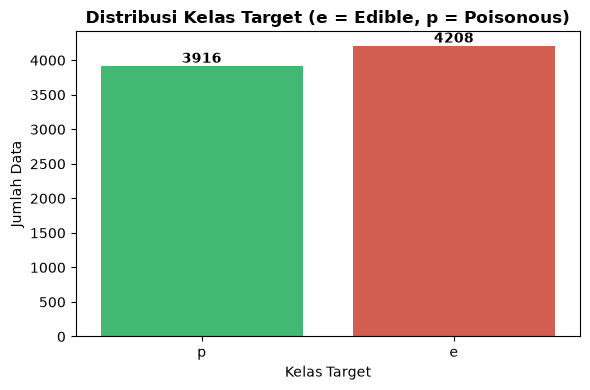

In [303]:
plt.figure(figsize=(6, 4))

# Countplot dengan warna perbaikan
ax = sns.countplot(
    x='class', 
    data=df, 
    palette=['#2ecc71', '#e74c3c'], 
    hue='class', 
    legend=False
)

# Pengaturan Judul & Label Axis
plt.title('Distribusi Kelas Target (e = Edible, p = Poisonous)', fontsize=12, fontweight='bold')
plt.xlabel('Kelas Target', fontsize=10)
plt.ylabel('Jumlah Data', fontsize=10)

# Menambahkan angka jumlah di atas setiap batang plot
for p in ax.patches:
    height = int(p.get_height())
    ax.annotate(f'{height}',
                (p.get_x() + p.get_width() / 2., height),
                ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()


## 3. Analisis Univariat

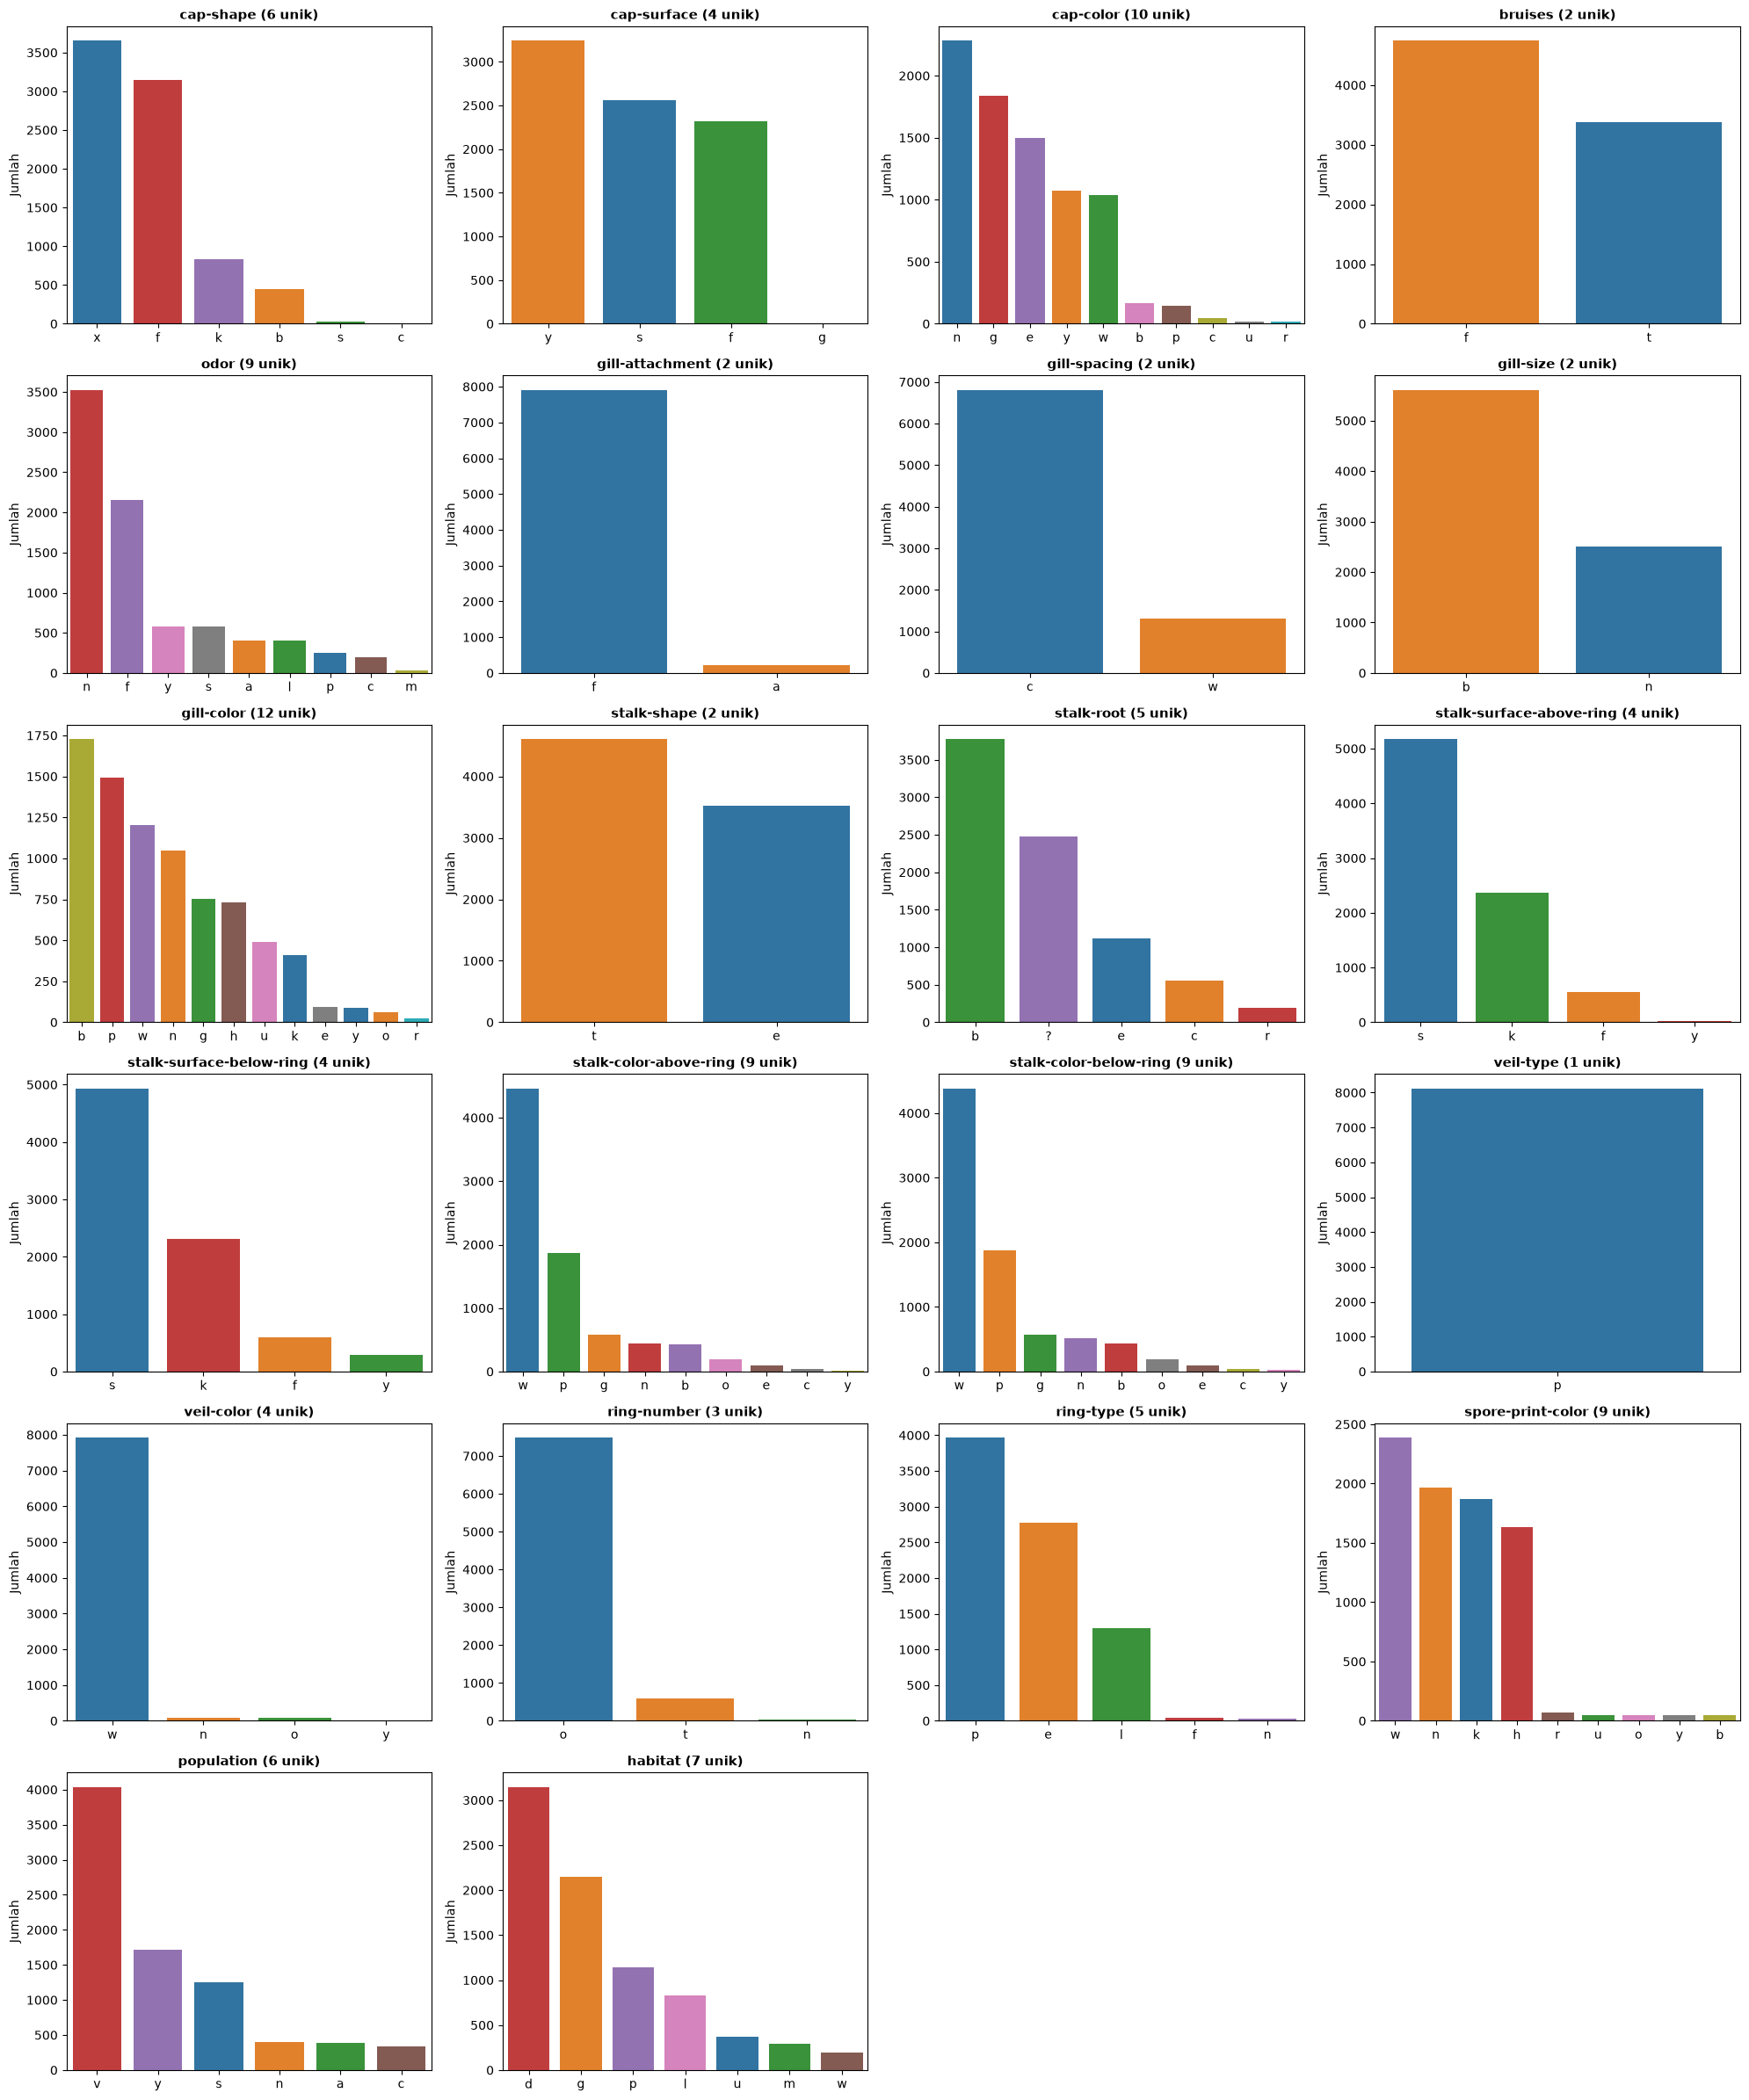

In [304]:
# Ambil semua kolom kecuali target 'class'
features = [col for col in df.columns if col != 'class']

# Buat grid 6x4 (total 24 slot untuk 22 fitur)
fig, axes = plt.subplots(6, 4, figsize=(20, 24))
axes = axes.flatten()

for i, col in enumerate(features):
    order = df[col].value_counts().index
    sns.countplot(x=col, data=df, order=order, ax=axes[i], palette='tab10', hue=col, legend=False)
    axes[i].set_title(f'{col} ({df[col].nunique()} unik)', fontsize=11, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Jumlah')

# Hapus 2 subplot sisa yang kosong di akhir grid
for j in range(len(features), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


## 4. Analisis Bivariat

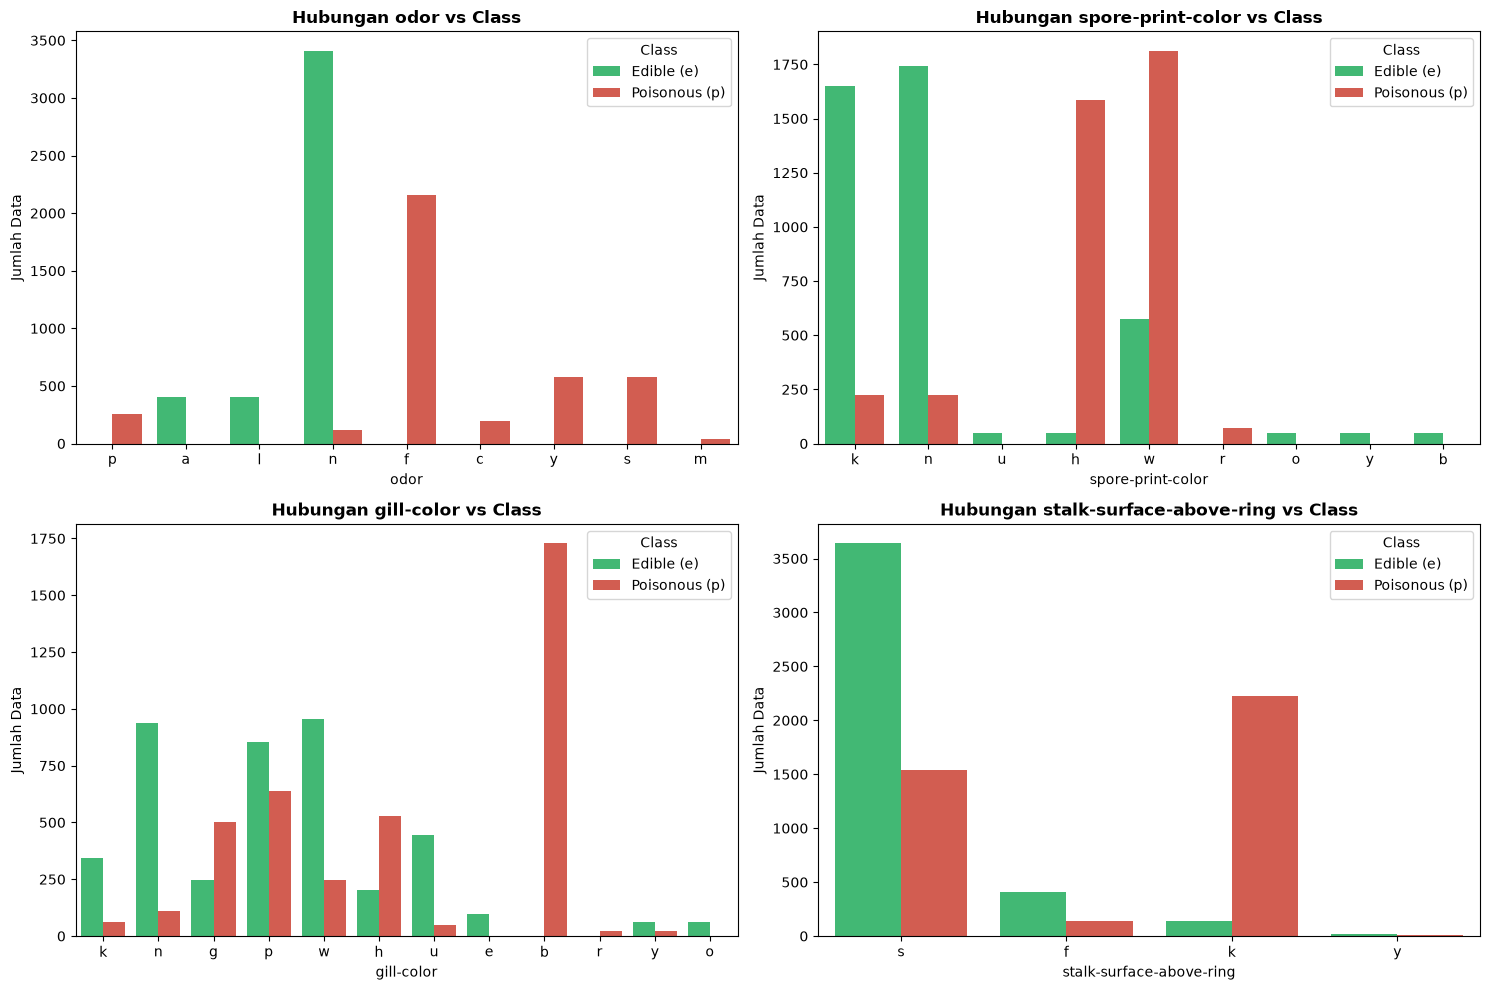

In [305]:
fitur_bivariat = ['odor', 'spore-print-color', 'gill-color', 'stalk-surface-above-ring']
color_dict = {'e': '#2ecc71', 'p': '#e74c3c'} # e = Hijau, p = Merah

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.flatten()

for i, col in enumerate(fitur_bivariat):
    sns.countplot(
        x=col, 
        hue='class', 
        data=df, 
        ax=axes[i], 
        palette=color_dict,
        hue_order=['e', 'p']
    )
    axes[i].set_title(f'Hubungan {col} vs Class', fontsize=12, fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Jumlah Data')
    axes[i].legend(
        title='Class', 
        labels=['Edible (e)', 'Poisonous (p)'],
        loc='upper right'
    )

plt.tight_layout()
plt.show()


Cek dominansi kategori 

In [306]:
dominant_data = []

for col in df.columns:
    top_cat = df[col].value_counts().index[0]
    top_count = df[col].value_counts().iloc[0]
    top_pct = (df[col].value_counts(normalize=True).iloc[0]) * 100
    
    if top_pct > 90:  # Ambang batas > 90%
        # Memberikan keterangan rekomendasi
        if top_pct == 100:
            rekomendasi = "Konstan 100% (Wajib Drop)"
        else:
            rekomendasi = "Variansi Sangat Rendah (Low Variance)"
            
        dominant_data.append({
            'Nama Fitur': col,
            'Kategori Dominan': top_cat,
            'Jumlah Baris': top_count,
            'Persentase (%)': round(top_pct, 2),
            'Keterangan / Rekomendasi': rekomendasi
        })

# Buat DataFrame
df_dominant = pd.DataFrame(dominant_data)

print("=== Tabel Fitur dengan Kategori Sangat Dominan (> 90%) ===")
display(df_dominant)


=== Tabel Fitur dengan Kategori Sangat Dominan (> 90%) ===


,Nama Fitur,Kategori Dominan,Jumlah Baris,Persentase (%),Keterangan / Rekomendasi
0,gill-attachment,f,7914,97.42,Variansi Sangat Rendah (Low Variance)
1,veil-type,p,8124,100.00,Konstan 100% (Wajib Drop)
2,veil-color,w,7924,97.54,Variansi Sangat Rendah (Low Variance)
3,ring-number,o,7488,92.17,Variansi Sangat Rendah (Low Variance)


Cek kelangkaan kategori pada setiap kolom

In [307]:
# kumpulkan data kategori langka ke dalam list
rare_data = []

for col in df.columns:
    counts_abs = df[col].value_counts()
    counts_pct = df[col].value_counts(normalize=True) * 100
    
    for category in counts_pct.index:
        if counts_pct[category] < 1.0: # Ambang batas < 1%
            rare_data.append({
                'Fitur': col,
                'Kategori Langka': category,
                'Jumlah Baris': counts_abs[category],
                'Persentase (%)': round(counts_pct[category], 3)
            })

# Buat DataFrame
df_rare = pd.DataFrame(rare_data)

print("=== Tabel Kategori Langka (< 1% dari Total Data) ===")
display(df_rare)


=== Tabel Kategori Langka (< 1% dari Total Data) ===


,Fitur,Kategori Langka,Jumlah Baris,Persentase (%)
0,cap-shape,s,32,0.394
1,cap-shape,c,4,0.049
2,cap-surface,g,4,0.049
3,cap-color,c,44,0.542
4,cap-color,u,16,0.197
5,cap-color,r,16,0.197
6,odor,m,36,0.443
7,gill-color,o,64,0.788
8,gill-color,r,24,0.295
9,stalk-surface-above-ring,y,24,0.295


## 5. Matrix Korelasi

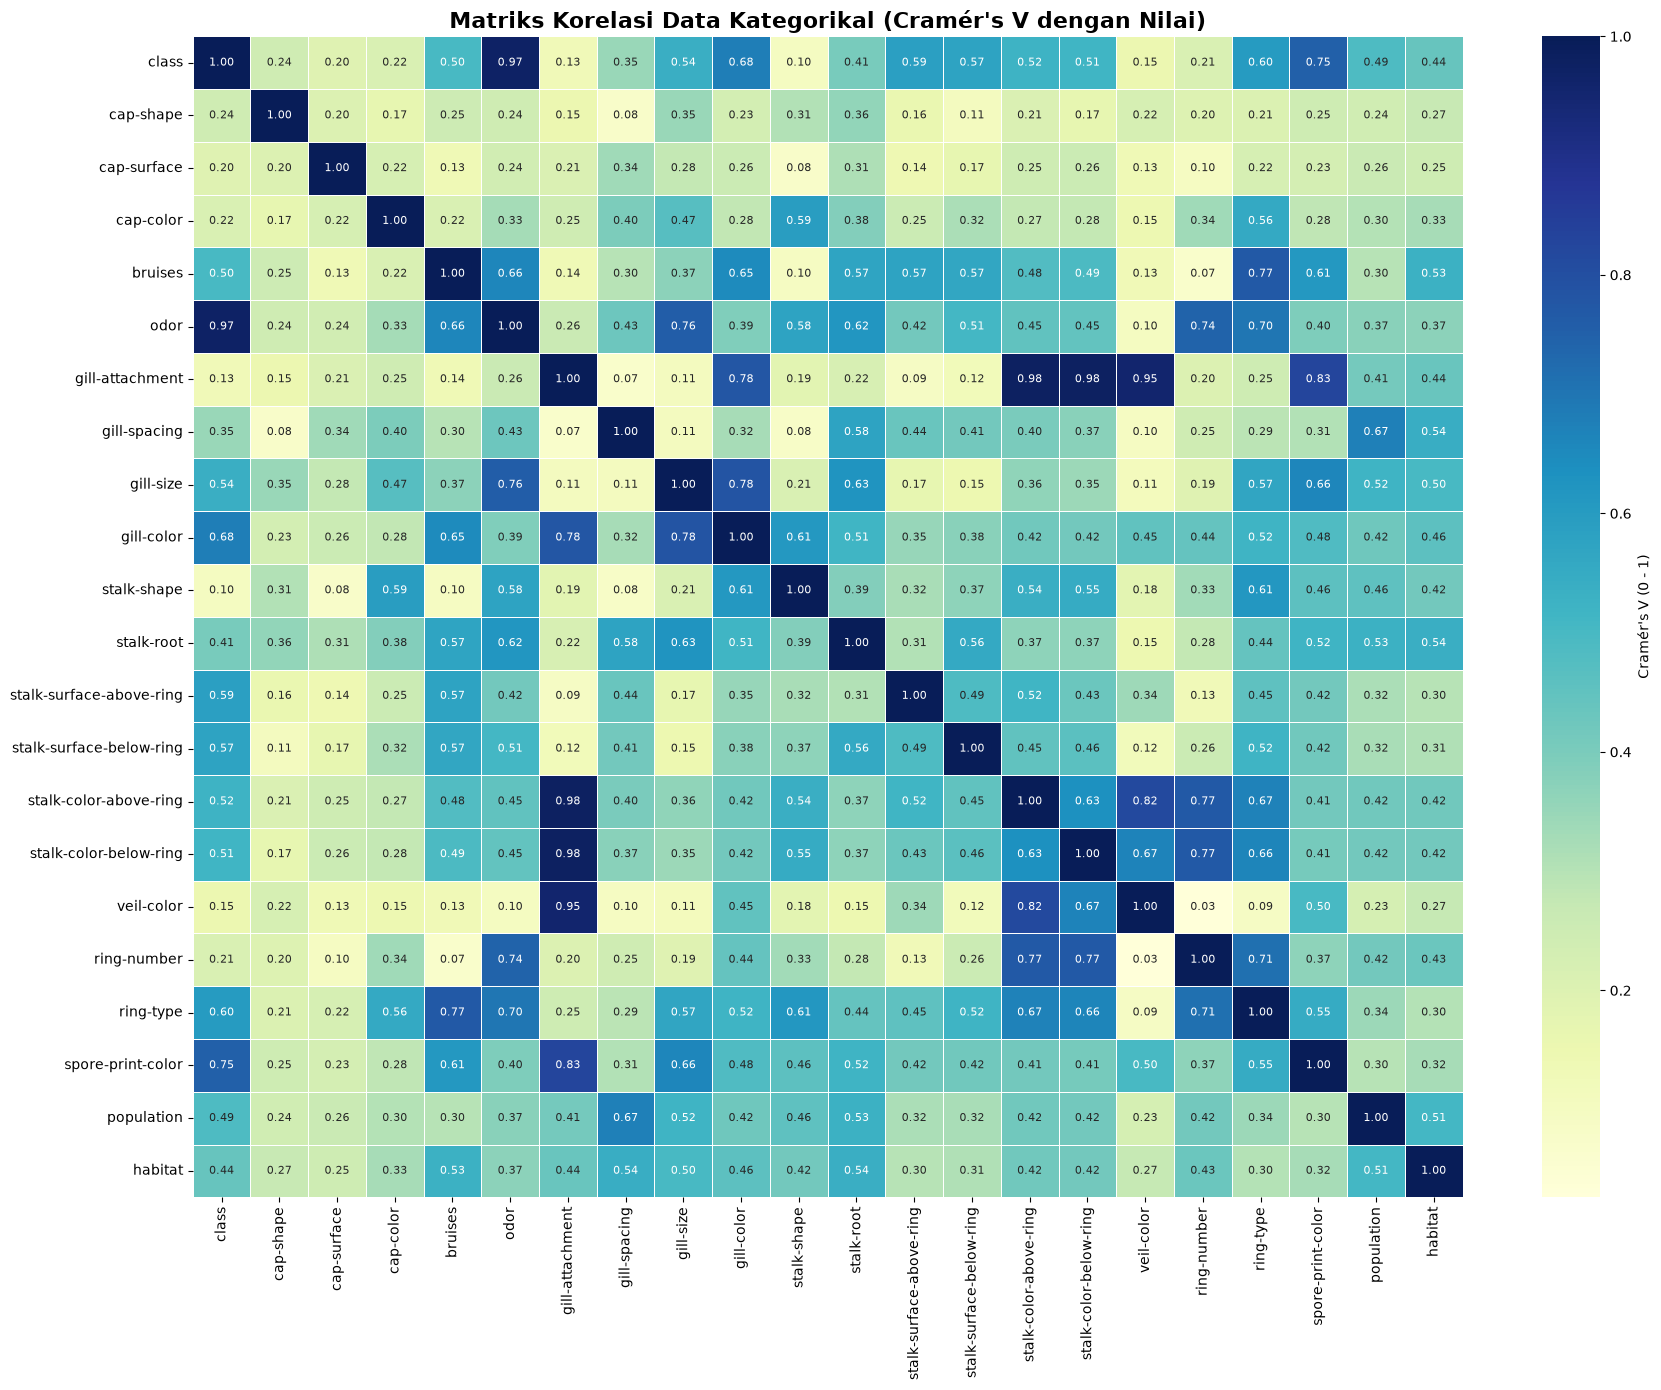

In [308]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency

# 1. Fungsi Matematika Cramér's V
def cramers_v(x, y):
    confusion_matrix = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    phi2 = chi2 / n
    r, k = confusion_matrix.shape
    
    r_corr = r - ((r - 1) ** 2) / (n - 1)
    k_corr = k - ((k - 1) ** 2) / (n - 1)
    min_dim = min((k_corr - 1), (r_corr - 1))
    
    if min_dim <= 0:
        return 0.0
        
    phi2_corr = max(0, phi2 - ((k - 1) * (r - 1)) / (n - 1))
    return np.sqrt(phi2_corr / min_dim)

# 2. Hapus 'veil-type' sementara agar tidak error
df_corr = df.drop(columns=['veil-type']) if 'veil-type' in df.columns else df.copy()

# 3. Hitung Matriks Korelasi Cramér's V
cols = df_corr.columns
cramer_matrix = pd.DataFrame(index=cols, columns=cols, dtype=float)

for col1 in cols:
    for col2 in cols:
        cramer_matrix.loc[col1, col2] = cramers_v(df_corr[col1], df_corr[col2])

# 4. Visualisasi Heatmap Berangka (annot=True)
plt.figure(figsize=(18, 14)) # Ukuran diperbesar agar angka muat dengan jelas
sns.heatmap(
    cramer_matrix, 
    cmap='YlGnBu', 
    annot=True,              # Tampilkan angka di dalam kotak
    fmt='.2f',               # Format 2 angka di belakang koma
    annot_kws={'size': 8},    # Ukuran font angka di dalam kotak
    linewidths=0.5,
    cbar_kws={'label': "Cramér's V (0 - 1)"}
)

plt.title("Matriks Korelasi Data Kategorikal (Cramér's V dengan Nilai)", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()


## Lakukan Exploratory Data Analysis (EDA) tambahan yang diperlukan.

# 2. Preprocessing

Karena semua fitur bertipe kategorikal, setiap varian Naive Bayes membutuhkan representasi data yang berbeda:

| Model | Representasi yang dibutuhkan | Preprocessing |
|---|---|---|
| Categorical NB | Integer per kategori | OrdinalEncoder |
| Bernoulli NB | Binary 0/1 per kategori | LabelBinarizer / OneHotEncoder |
| Multinomial NB | Count / frekuensi non-negatif | OneHotEncoder |

Tangani Missing Value

In [309]:
# Tangani missing value pada kolom stalk-root (nilai '?').
# Pilih strategi yang sesuai: drop baris, ganti dengan modus, atau jadikan kategori tersendiri.

# Mengganti karakter '?' menjadi kategori baru 'missing'
df['stalk-root'] = df['stalk-root'].replace('?', 'missing')

# Cek kembali distribusi nilai pada kolom stalk-root
print("=== Distribusi Kolom stalk-root Setelah Penanganan Missing Value ===")
print(df['stalk-root'].value_counts())

# Pastikan tidak ada lagi karakter '?' tersisa
print("\nSisa karakter '?' di dataset:", (df == '?').sum().sum())


=== Distribusi Kolom stalk-root Setelah Penanganan Missing Value ===
stalk-root
b          3776
missing    2480
e          1120
c           556
r           192
Name: count, dtype: int64

Sisa karakter '?' di dataset: 0


Periksa fitur yang hanya memiliki 1 nilai unik lalu di drop

In [310]:
# Periksa apakah ada fitur yang hanya memiliki satu nilai unik.
# Fitur seperti itu tidak memberikan informasi apapun dan sebaiknya di-drop.

# 1. Cari otomatis kolom yang hanya memiliki 1 nilai unik
fitur_konstan = [col for col in df.columns if df[col].nunique() == 1]
print(f"Fitur dengan 1 nilai unik yang ditemukan: {fitur_konstan}")

# 2. Hapus (drop) fitur konstan tersebut dari dataset
df = df.drop(columns=fitur_konstan)

# 3. Verifikasi jumlah kolom setelah di-drop
print(f"Jumlah kolom dataset sekarang: {df.shape[1]} kolom")


Fitur dengan 1 nilai unik yang ditemukan: ['veil-type']
Jumlah kolom dataset sekarang: 22 kolom


Pisahkan fitur x dan y dan splitting data train dan data test

In [311]:
# Pisahkan fitur (X) dan target (y).
# Encode target: e = 0 (edible), p = 1 (poisonous).
# Bagi data menjadi train set dan test set (misalnya 80:20).
# Gunakan stratify=y agar distribusi kelas tetap proporsional.

# 1. Pisahkan fitur (X) dan target (y)
X = df.drop(columns=['class'])
y = df['class']

# 2. Encode target: e = 0 (edible), p = 1 (poisonous)
y = y.map({'e': 0, 'p': 1})

# 3. Bagi data menjadi train set dan test set (80:20) dengan stratify=y
X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y
)

# 4. Tampilkan Verifikasi Hasil Pembagian Data
print("Dimensi Data Hasil Split")
print(f"X_train: {X_train.shape}")
print(f"X_test : {X_test.shape}")
print(f"y_train: {y_train.shape}")
print(f"y_test : {y_test.shape}\n")

print("Proporsi Kelas Target di Train Set (%)")
print((y_train.value_counts(normalize=True) * 100).round(2))

print("\nProporsi Kelas Target di Test Set (%)")
print((y_test.value_counts(normalize=True) * 100).round(2))


Dimensi Data Hasil Split
X_train: (6499, 21)
X_test : (1625, 21)
y_train: (6499,)
y_test : (1625,)

Proporsi Kelas Target di Train Set (%)
class
0    51.79
1    48.21
Name: proportion, dtype: float64

Proporsi Kelas Target di Test Set (%)
class
0    51.82
1    48.18
Name: proportion, dtype: float64


Preprocessung untuk Categorical NB

In [312]:
# Preprocessing untuk Categorical NB:
# Gunakan OrdinalEncoder untuk mengubah setiap kategori menjadi integer.
# Contoh: cap-shape b=0, c=1, f=2, k=3, s=4, x=5
# Fit hanya pada train set, transform pada train set dan test set.

# 1. Inisialisasi OrdinalEncoder
# handle_unknown='use_encoded_value' & unknown_value=-1 menjaga agar tidak error jika ada kategori asing di test set
ordinal_encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)

# 2. Fit HANYA pada X_train, lalu transform X_train
X_train_ord = ordinal_encoder.fit_transform(X_train)

# 3. Transform X_test menggunakan encoder yang sudah di-fit dari X_train
X_test_ord = ordinal_encoder.transform(X_test)

# 4. Verifikasi Hasil Encoding
print("=== Bentuk Array Hasil Ordinal Encoding ===")
print(f"X_train_ord shape: {X_train_ord.shape}")
print(f"X_test_ord shape : {X_test_ord.shape}\n")

print("=== Contoh 2 Baris Pertama X_train Asli (Teks) ===")
display(X_train.head(2))

print("=== Contoh 2 Baris Pertama X_train_ord (Angka Integer) ===")
print(X_train_ord[:2])


=== Bentuk Array Hasil Ordinal Encoding ===
X_train_ord shape: (6499, 21)
X_test_ord shape : (1625, 21)

=== Contoh 2 Baris Pertama X_train Asli (Teks) ===


,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,stalk-shape,...,stalk-surface-above-ring,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-color,ring-number,ring-type,spore-print-color,population,habitat
5249,f,y,y,f,f,f,c,b,g,e,...,k,k,p,b,w,o,l,h,y,g
5781,x,s,p,t,n,f,c,b,e,e,...,s,s,e,w,w,t,e,w,c,w


=== Contoh 2 Baris Pertama X_train_ord (Angka Integer) ===
[[2. 3. 9. 0. 2. 1. 0. 0. 2. 0. 0. 1. 1. 6. 0. 2. 1. 2. 1. 5. 1.]
 [5. 2. 5. 1. 5. 1. 0. 0. 1. 0. 3. 2. 2. 2. 7. 2. 2. 0. 7. 1. 6.]]


Preprocessing untuk Bernoulli NB dan Multinomial NB

In [313]:
# Preprocessing untuk Bernoulli NB dan Multinomial NB:
# Gunakan OneHotEncoder untuk mengubah setiap kategori menjadi representasi binary.
# Hasilnya berupa matriks sparse dengan nilai 0 dan 1.
# Fit hanya pada train set, transform pada train set dan test set.

# 1. Inisialisasi OneHotEncoder
# handle_unknown='ignore' menjaga agar tidak error jika ada kategori baru di test set
ohe_encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=True)

# 2. Fit HANYA pada X_train, lalu transform X_train
X_train_ohe = ohe_encoder.fit_transform(X_train)

# 3. Transform X_test menggunakan encoder yang sudah di-fit dari X_train
X_test_ohe = ohe_encoder.transform(X_test)

# 4. Verifikasi Hasil Encoding
print("=== Dimensi Matriks Hasil One-Hot Encoding ===")
print(f"X_train_ohe shape: {X_train_ohe.shape}  (Jumlah kolom bertambah jadi biner)")
print(f"X_test_ohe shape : {X_test_ohe.shape}\n")

print("=== Tipe Data Hasil Encoding ===")
print(type(X_train_ohe))  # Berupa scipy.sparse matrix


=== Dimensi Matriks Hasil One-Hot Encoding ===
X_train_ohe shape: (6499, 116)  (Jumlah kolom bertambah jadi biner)
X_test_ohe shape : (1625, 116)

=== Tipe Data Hasil Encoding ===
<class 'scipy.sparse._csr.csr_matrix'>


Cek Matrix OHE

In [314]:
# 1. Mengintip 5 baris pertama dalam bentuk array 0 dan 1
print("=== Contoh 5 Baris Pertama Hasil OHE (Array 0 dan 1) ===")
print(X_train_ohe[:5].toarray())

print("\n" + "="*50 + "\n")

# 2. Mengintip dalam bentuk Tabel DataFrame dengan Nama Kolom Binernya
# Ambil nama-nama kolom biner yang dibuat oleh OneHotEncoder
nama_kolom_biner = ohe_encoder.get_feature_names_out()

df_ohe_preview = pd.DataFrame(
    X_train_ohe[:5].toarray(), 
    columns=nama_kolom_biner
)

print("=== Contoh Tampilan Tabel Hasil One-Hot Encoding (5 Baris) ===")
display(df_ohe_preview)


=== Contoh 5 Baris Pertama Hasil OHE (Array 0 dan 1) ===
[[0. 0. 1. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 1. 0. 0. 0.
  1. 0. 0. 0. 0. 0. 0. 0. 1. 1. 0. 1. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 1. 0. 1. 0. 0. 0. 0. 0. 1. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0.
  0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 1. 0. 0. 0. 1. 0. 0. 0. 1.
  0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 1. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 1. 0. 0. 1. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 1. 0. 0.
  0. 0. 0. 1. 0. 0. 0. 0. 1. 1. 0. 1. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 1. 0. 0. 0. 0. 1. 0. 0. 0. 1. 0. 0. 0. 1. 0. 0. 0. 1. 0. 0. 0. 0. 0.
  0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 1. 0. 0. 0. 1. 1. 0. 0. 0. 0. 0. 0.
  0. 0. 0. 0. 0. 1. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]
 [1. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0.
  0. 0. 0. 1. 0. 0. 0. 0. 1. 0. 1. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1.
  0. 1. 0. 0. 0. 0. 1. 0. 0. 1. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 1.
  0

,cap-shape_b,cap-shape_c,cap-shape_f,cap-shape_k,cap-shape_s,cap-shape_x,cap-surface_f,cap-surface_g,cap-surface_s,cap-surface_y,...,population_s,population_v,population_y,habitat_d,habitat_g,habitat_l,habitat_m,habitat_p,habitat_u,habitat_w
0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


# 3. Eksperimen Model

## 3.1 Categorical Naive Bayes

CategoricalNB adalah varian yang paling sesuai untuk dataset ini karena semua fitur memang bertipe kategorikal. Model menghitung P(fitur=kategori | kelas) secara langsung untuk setiap kategori pada setiap fitur.

In [315]:
n_categories = [X[col].nunique() for col in X.columns]

In [316]:
# Inisialisasi dan latih model CategoricalNB menggunakan train set hasil OrdinalEncoder.
cat_nb = CategoricalNB(min_categories=n_categories, alpha=0.05)
cat_nb.fit(X_train_ord, y_train)

,"alpha alpha: float, default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",0.05
,"min_categories min_categories: int or array-like of shape (n_features,), default=NoneMinimum number of categories per feature.- integer: Sets the minimum number of categories per feature to `n_categories` for each features.- array-like: shape (n_features,) where `n_categories[i]` holds the minimum number of categories for the ith column of the input.- None (default): Determines the number of categories automatically from the training data... versionadded:: 0.24","[6, 4, ...]"
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
Name,Type,Value
"category_count_ category_count_: list of arrays of shape (n_features,)Holds arrays of shape (n_classes, n_categories of respective feature)for each feature. Each array provides the number of samplesencountered for each class and category of the specific feature.",list,"[array([[ 324.... 0., 1382.]]), array([[1248....134., 1368.]]), array([[ 38.... 542.]]), array([[1161....634., 499.]]), ...]"
"class_count_ class_count_: ndarray of shape (n_classes,)Number of samples encountered for each class during fitting. Thisvalue is weighted by the sample weight when provided.","ndarray[float64](2,)","[3366.,3133.]"
"class_log_prior_ class_log_prior_: ndarray of shape (n_classes,)Smoothed empirical log probability for each class.","ndarray[float64](2,)","[-0.66,-0.73]"
"classes_ classes_: ndarray of shape (n_classes,)Class labels known to the classifier","ndarray[int64](2,)","[0,1]"
"feature_log_prob_ feature_log_prob_: list of arrays of shape (n_features,)Holds arrays of shape (n_classes, n_categories of respective feature)for each feature. Each array provides the empirical log probabilityof categories given the respective feature and class, ``P(x_i|y)``.",list,"[array([[ -2.3...-0.81851886]]), array([[ -0.9...-0.82866848]]), array([[ -4.4...-1.75454762]]), array([[-1.06...-1.83707192]]), ...]"


In [317]:
# Lakukan prediksi pada test set.
# Simpan hasil prediksi label dan probabilitas kelas 1 untuk keperluan evaluasi.
y_pred_cat = cat_nb.predict(X_test_ord)
y_proba_cat = cat_nb.predict_proba(X_test_ord)[:, 1]  # Probabilitas kelas 1 (poisonous)
print("CategoricalNB berhasil dilatih dan diprediksi.")

CategoricalNB berhasil dilatih dan diprediksi.


In [318]:
acc_cat = accuracy_score(y_test, y_pred_cat)
print("=== Categorical Naive Bayes ===")
print(f"Akurasi Test Set: {acc_cat * 100:.2f}%")

=== Categorical Naive Bayes ===
Akurasi Test Set: 98.22%


## 3.2 Bernoulli Naive Bayes

BernoulliNB bekerja pada representasi binary. Dengan OneHotEncoder, setiap kategori menjadi kolom tersendiri bernilai 0 atau 1, sehingga model memperlakukan setiap kategori sebagai fitur binary ada/tidak ada.

In [319]:
# Inisialisasi dan latih model BernoulliNB menggunakan train set hasil OneHotEncoder.
ber_nb = BernoulliNB(alpha=0.05)
ber_nb.fit(X_train_ohe, y_train)

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",0.05
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"binarize binarize: float or None, default=0.0Threshold for binarizing (mapping to booleans) of sample features.If None, input is presumed to already consist of binary vectors.",0.0
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
Name,Type,Value
"class_count_ class_count_: ndarray of shape (n_classes,)Number of samples encountered for each class during fitting. Thisvalue is weighted by the sample weight when provided.","ndarray[float64](2,)","[3366.,3133.]"
"class_log_prior_ class_log_prior_: ndarray of shape (n_classes,)Log probability of each class (smoothed).","ndarray[float64](2,)","[-0.66,-0.73]"
"classes_ classes_: ndarray of shape (n_classes,)Class labels known to the classifier","ndarray[int64](2,)","[0,1]"
"feature_count_ feature_count_: ndarray of shape (n_classes, n_features)Number of samples encountered for each (class, feature)during fitting. This value is weighted by the sample weight whenprovided.","ndarray[float64](2, 116)","[[ 324., 0.,1276.,..., 109., 80., 157.], [ 37., 4.,1241.,..., 782., 221., 0.]]"
"feature_log_prob_ feature_log_prob_: ndarray of shape (n_classes, n_features)Empirical log probability of features given a class, P(x_i|y).","ndarray[float64](2, 116)","[[ -2.34,-11.12, -0.97,..., -3.43, -3.74, -3.06], [ -4.44, -6.65, -0.93,..., -1.39, -2.65,-11.05]]"


In [320]:
# Lakukan prediksi pada test set.
# Simpan hasil prediksi label dan probabilitas kelas 1 untuk keperluan evaluasi.

y_pred_ber = ber_nb.predict(X_test_ohe)
y_proba_ber = ber_nb.predict_proba(X_test_ohe)[:, 1]  # Probabilitas kelas 1 (poisonous)
print("BernoulliNB berhasil dilatih dan diprediksi.")

BernoulliNB berhasil dilatih dan diprediksi.


In [321]:
acc_ber = accuracy_score(y_test, y_pred_ber)
print("=== Bernoulli Naive Bayes ===")
print(f"Akurasi Test Set: {acc_ber * 100:.2f}%")

=== Bernoulli Naive Bayes ===
Akurasi Test Set: 96.62%


## 3.3 Multinomial Naive Bayes

MultinomialNB membutuhkan input non-negatif dan menginterpretasikannya sebagai frekuensi. Dengan OneHotEncoder yang menghasilkan nilai 0 dan 1, model dapat menerimanya sebagai counts meskipun secara semantik tiap nilai hanya menandakan ada/tidak ada kategori.

In [322]:
# Inisialisasi dan latih model MultinomialNB menggunakan train set hasil OneHotEncoder.

mul_nb = MultinomialNB(alpha=0.05)
mul_nb.fit(X_train_ohe, y_train)

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",0.05
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
Name,Type,Value
"class_count_ class_count_: ndarray of shape (n_classes,)Number of samples encountered for each class during fitting. Thisvalue is weighted by the sample weight when provided.","ndarray[float64](2,)","[3366.,3133.]"
"class_log_prior_ class_log_prior_: ndarray of shape (n_classes,)Smoothed empirical log probability for each class.","ndarray[float64](2,)","[-0.66,-0.73]"
"classes_ classes_: ndarray of shape (n_classes,)Class labels known to the classifier","ndarray[int64](2,)","[0,1]"
"feature_count_ feature_count_: ndarray of shape (n_classes, n_features)Number of samples encountered for each (class, feature)during fitting. This value is weighted by the sample weight whenprovided.","ndarray[float64](2, 116)","[[ 324., 0.,1276.,..., 109., 80., 157.], [ 37., 4.,1241.,..., 782., 221., 0.]]"
"feature_log_prob_ feature_log_prob_: ndarray of shape (n_classes, n_features)Empirical log probability of featuresgiven a class, ``P(x_i|y)``.","ndarray[float64](2, 116)","[[ -5.39,-14.16, -4.01,..., -6.47, -6.78, -6.11], [ -7.48, -9.7 , -3.97,..., -4.43, -5.7 ,-14.09]]"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,116


In [323]:
# Lakukan prediksi pada test set.
# Simpan hasil prediksi label dan probabilitas kelas 1 untuk keperluan evaluasi.

y_pred_mul = mul_nb.predict(X_test_ohe)
y_proba_mul = mul_nb.predict_proba(X_test_ohe)[:, 1]  # Probabilitas kelas 1 (poisonous)
print("MultinomialNB berhasil dilatih dan diprediksi.")

MultinomialNB berhasil dilatih dan diprediksi.


In [324]:
acc_mul = accuracy_score(y_test, y_pred_mul)
print("=== Multinomial Naive Bayes ===")
print(f"Akurasi Test Set: {acc_mul * 100:.2f}%")

=== Multinomial Naive Bayes ===
Akurasi Test Set: 98.22%


# 4. Evaluasi Model

In [325]:
# Tampilkan metrik evaluasi untuk setiap model: Accuracy, Precision, Recall, dan F1-Score.
# Sajikan dalam satu tabel perbandingan agar mudah dibandingkan.

models = {
    'Categorical NB': (y_pred_cat, y_proba_cat),
    'Bernoulli NB': (y_pred_ber, y_proba_ber),
    'Multinomial NB': (y_pred_mul, y_proba_mul)
}

metrics_data = []

for name, (y_pred, y_proba) in models.items():
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    
    metrics_data.append({
        'Model': name,
        'Accuracy': round(acc, 4),
        'Precision': round(prec, 4),
        'Recall': round(rec, 4),
        'F1-Score': round(f1, 4)
    })

df_eval = pd.DataFrame(metrics_data)
print("Tabel Perbandingan Metrik Evaluasi Model")
display(df_eval)


Tabel Perbandingan Metrik Evaluasi Model


,Model,Accuracy,Precision,Recall,F1-Score
0,Categorical NB,0.9822,0.9909,0.9719,0.9813
1,Bernoulli NB,0.9662,0.9879,0.9413,0.9640
2,Multinomial NB,0.9822,0.9909,0.9719,0.9813


# 5. Confusion Matrix

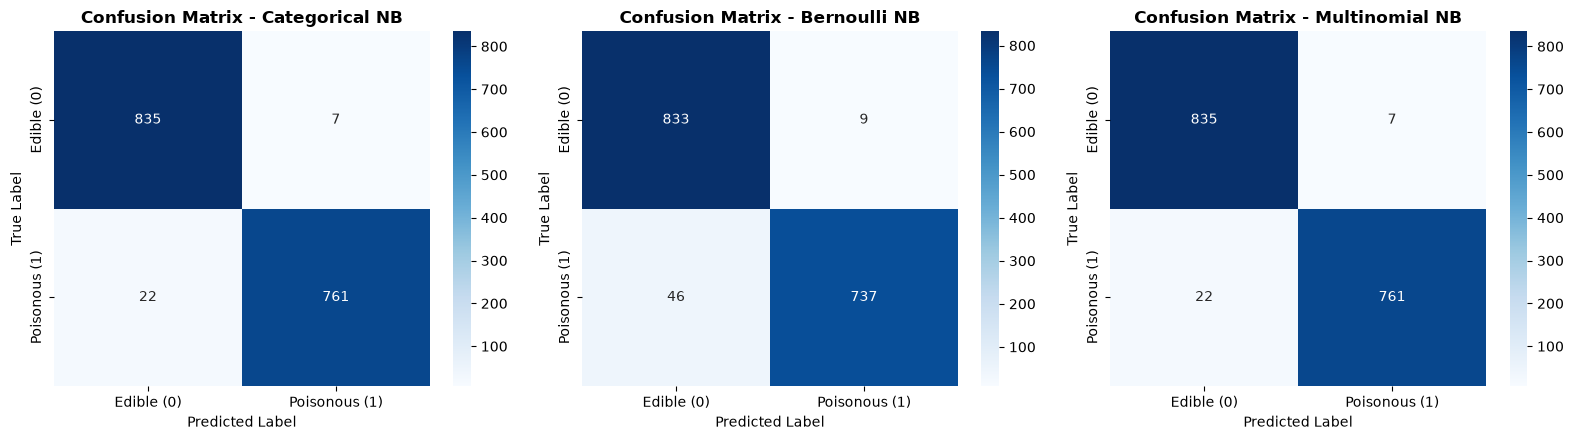

In [326]:
# Tampilkan Confusion Matrix setiap model dalam bentuk heatmap.
# Susun ketiganya dalam satu baris subplot.
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

model_preds = [
    ('Categorical NB', y_pred_cat),
    ('Bernoulli NB', y_pred_ber),
    ('Multinomial NB', y_pred_mul)
]

for idx, (title, y_pred) in enumerate(model_preds):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx],
                xticklabels=['Edible (0)', 'Poisonous (1)'],
                yticklabels=['Edible (0)', 'Poisonous (1)'])
    axes[idx].set_title(f'Confusion Matrix - {title}', fontweight='bold')
    axes[idx].set_xlabel('Predicted Label')
    axes[idx].set_ylabel('True Label')

plt.tight_layout()
plt.show()


# 6. ROC Curve

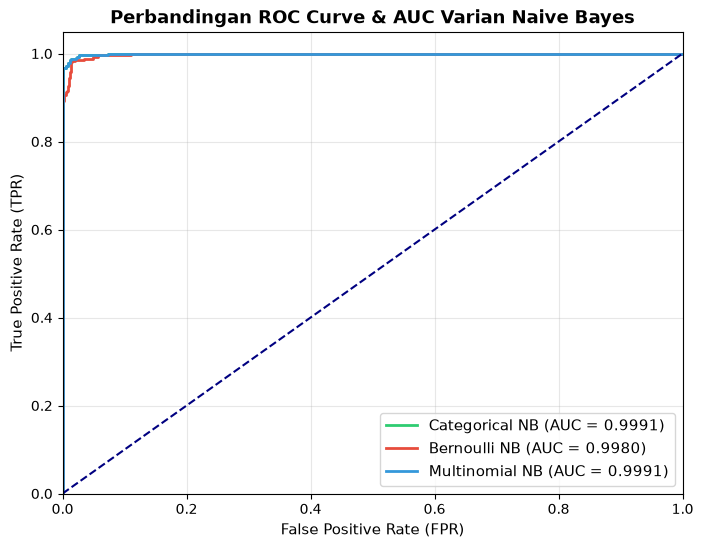

In [327]:
# Tampilkan ROC Curve ketiga model dalam satu plot beserta nilai AUC masing-masing.

plt.figure(figsize=(8, 6))

model_probas = [
    ('Categorical NB', y_proba_cat, '#2ecc71'),
    ('Bernoulli NB', y_proba_ber, '#e74c3c'),
    ('Multinomial NB', y_proba_mul, '#3498db')
]

for title, y_proba, color in model_probas:
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=color, lw=2, label=f'{title} (AUC = {roc_auc:.4f})')

plt.plot([0, 1], [0, 1], color='navy', lw=1.5, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (FPR)', fontsize=11)
plt.ylabel('True Positive Rate (TPR)', fontsize=11)
plt.title('Perbandingan ROC Curve & AUC Varian Naive Bayes', fontsize=13, fontweight='bold')
plt.legend(loc="lower right", fontsize=11)
plt.grid(True, alpha=0.3)
plt.show()


# 6. Analisis

5. Analisis Hasil Eksperimen

1. Gambaran Umum dan Performa Model Utama (alpha = 0.05)
Dari pengujian pada 1.625 data uji jamur, memilih nilai alpha = 0.05 dan parameter min_categories sebagai konfigurasi utama. Hasilnya cukup impresif:
- Categorical Naive Bayes (Categorical NB): Akurasi 98.22 persen, Presisi 99.09 persen, Recall 97.19 persen, dan F1-Score 98.13 persen.
- Multinomial Naive Bayes (Multinomial NB): Akurasi 98.22 persen, Presisi 99.09 persen, Recall 97.19 persen, dan F1-Score 98.13 persen.
- Bernoulli Naive Bayes (Bernoulli NB): Akurasi 96.62 persen, Presisi 98.79 persen, Recall 94.13 persen, dan F1-Score 96.40 persen.

Bisa dilihat, Categorical NB dan Multinomial NB jadi model terbaik karena punya skor yang tinggi dan sama persis, sedangkan Bernoulli NB menyusul sedikit di belakangnya.

2. Pengaruh Bentuk Data (Encoding) terhadap Performa
Perbedaan skor tiap model ternyata sangat dipengaruhi oleh cara mereka membaca format data:
- Categorical NB membaca 21 kolom kategorikal asli hasil OrdinalEncoder. Model ini memang dari lahir dirancang untuk menangani data yang punya banyak variasi kategori.
- Multinomial NB memproses 116 kolom biner hasil OneHotEncoder. Uniknya, model ini hanya menghitung ciri yang muncul (angka 1) dan mengabaikan angka 0. Makanya kinerjanya bisa menyamai Categorical NB di angka 98.22 persen.
- Bernoulli NB ikut memperhitungkan angka 1 dan angka 0 sekaligus dari 116 kolom biner. Penumpukan puluhan angka 0 ini malah jadi pengganggu (noise) yang menahan akurasi Bernoulli NB di angka 96.62 persen.

3. Temuan Ciri Khusus Jamur (Fitur Dominan)
Hasil eksperimen ini sejalan dengan analisis eksplorasi data (EDA) awal, yaitu fitur bau jamur (odor) adalah penentu paling sakti:
- Jamur berbau almond dan adas manis (anise) 100 persen aman dimakan.
- Jamur yang berbau busuk (foul) 100 persen beracun.
Karena petunjuk dari fitur bau ini sangat jelas, semua varian Naive Bayes bisa dengan mudah meraih akurasi di atas 95 persen.

4. Pengaruh Parameter Alpha (Smoothing) dan min_categories
Mengatur nilai alpha dan min_categories memberikan dampak yang terasa sekali:
- Pakai bawaan (alpha = 1.0 dan tanpa min_categories): Model cuma dapat akurasi terendah di angka 94.50 persen karena efek peratannya terlalu tebal.
- Dituning ke alpha = 0.1: Akurasi langsung melesat ke 97.72 persen karena sinyal dari fitur bau bisa terbaca lebih jelas dan tajam.
- Dituning lagi ke alpha = 0.05 (Pilihan Utama): Akurasi naik lagi sampai 98.22 persen. Angka 0.05 ini pas banget buat menjaga ketajaman sinyal fitur tanpa kehilangan fungsi pengamannya.

5. Uji Coba Ekstrem (alpha = 0.0001) dan Kenapa Tidak Dipilih
Saat mencoba eksperimen ekstrem dengan mengecilkan alpha ke 0.0001, angka di tabel memang terlihat makin meroket:
- Categorical NB dan Multinomial NB naik ke Akurasi 99.38 persen, Presisi 99.11 persen, Recall 99.62 persen, dan F1-Score 99.36 persen.
- Bernoulli NB naik ke Akurasi 98.77 persen, Presisi 98.85 persen, Recall 98.60 persen, dan F1-Score 98.72 persen.

Walaupun skornya terlihat menggiurkan, kita sengaja tidak memilih alpha = 0.0001 sebagai model utama karena dua alasan penting:
- Risiko Overfitting: Memperkecil alpha mendekati nol sama saja dengan mematikan fungsi pelicin (smoothing), sehingga model jadi terlalu menghafal data latih.
- Rentan Gagal pada Data Baru: Kalau di kemudian hari ada jamur baru dengan ciri yang sedikit beda dari data latih, model tanpa smoothing akan kebingungan dan bisa salah tebak secara fatal.

Jadi, pilihan alpha = 0.05 adalah keputusan paling bijak karena performanya sudah sangat tinggi (98.22 persen) dan jauh lebih aman saat digunakan untuk menebak data baru.

# 7. Kesimpulan dan Saran

Model Terbaik Sesuai Eksperimen: Categorical NB dan Multinomial NB meraih performa tertinggi yang identik dengan akurasi 98.22 persen, presisi 99.09 persen, dan recall 97.19 persen. Sementara Bernoulli NB menyusul di bawahnya dengan akurasi 96.62 persen.

Fitur Paling Berpengaruh: Bau jamur (odor) merupakan fitur yang paling dominan. Jamur berbau almond dan adas manis 100 persen aman dimakan, sedangkan yang berbau busuk 100 persen beracun.

Pengaruh Format Data: Categorical NB bekerja sangat pas di 21 kolom asli, sedangkan Multinomial NB sukses memproses 116 kolom biner karena hanya fokus pada angka 1. Bernoulli NB sedikit terhambat oleh akumulasi noise dari banyaknya angka 0.

Tuning Parameter: alpha = 0.05 dan min_categories terbukti berhasil mendongkrak akurasi dari angka dasar 94.50 persen menjadi 98.22 persen. Kombinasi ini menjadi pilihan terbaik karena menghasilkan performa maksimal tanpa mengorbankan kemampuan model saat menebak data baru.